# Kakutani threshold

Hellinger products for the family of product Poisson measures $\mu_\sigma$.

**Claim evidenced.** The product Poisson measures
$\mu_\sigma = \bigotimes_p P_{p^{-\sigma}}(\theta_p)\,\frac{d\theta_p}{2\pi}$
change type at $\sigma = 1/2$: by Kakutani's dichotomy, equivalence to the
product of uniform measures holds iff the Hellinger product
$\prod_p H_p(\sigma)$ converges to a nonzero limit, where
$H_p(\sigma) = \int_{-\pi}^{\pi} \sqrt{P_{p^{-\sigma}}(\theta)}\,\frac{d\theta}{2\pi}$.
We compute the $H_p$ numerically, plot the partial products over
$\sigma \in [0.3, 1.0]$ for primes below $10^2, 10^3, 10^4$, and separately verify
the small-amplitude expansion $H = 1 - a^2/4 + O(a^4)$ that drives the dichotomy
($\sum_p a_p^2 = \sum_p p^{-2\sigma} < \infty \iff \sigma > 1/2$).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from sympy import primerange

theta = np.linspace(-math.pi, math.pi, 4001)
cos_theta = np.cos(theta)


def hellinger_local(a: np.ndarray) -> np.ndarray:
    """H(a) = (1/2pi) int_{-pi}^{pi} sqrt(P_a(theta)) dtheta for each amplitude in a."""
    a = np.atleast_1d(np.asarray(a, dtype=float))
    P = (1 - a[:, None] ** 2) / (1 - 2 * a[:, None] * cos_theta[None, :] + a[:, None] ** 2)
    return np.trapezoid(np.sqrt(P), theta, axis=1) / (2 * math.pi)

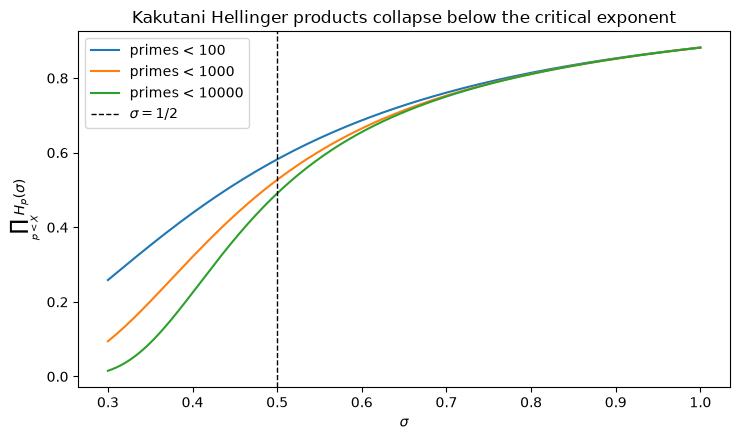

In [2]:
sigmas = np.linspace(0.3, 1.0, 141)
bounds = (100, 1000, 10000)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
products = {}
for bound in bounds:
    primes = np.array(list(primerange(2, bound)), dtype=float)
    prods = np.empty_like(sigmas)
    for k, s in enumerate(sigmas):
        H = hellinger_local(primes ** (-s))
        prods[k] = math.exp(float(np.sum(np.log(H))))
    products[bound] = prods
    ax.plot(sigmas, prods, label=f"primes < {bound}")
ax.axvline(0.5, color="k", ls="--", lw=1, label=r"$\sigma = 1/2$")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\prod_{p<X} H_p(\sigma)$")
ax.set_title("Kakutani Hellinger products collapse below the critical exponent")
ax.legend()
fig.tight_layout()
plt.show()

In [3]:
# Collapse vs stabilization, read off at a few exponents.
probe = [0.35, 0.45, 0.50, 0.55, 0.70, 1.00]
print(f"{'sigma':>6} " + " ".join(f"{f'X={b}':>12}" for b in bounds))
for s in probe:
    k = int(np.argmin(np.abs(sigmas - s)))
    row = " ".join(f"{products[b][k]:>12.6f}" for b in bounds)
    print(f"{sigmas[k]:>6.2f} {row}")

 sigma        X=100       X=1000      X=10000
  0.35     0.351443     0.201083     0.089974
  0.45     0.515399     0.432547     0.368935
  0.50     0.582116     0.527218     0.490955
  0.55     0.638861     0.603900     0.584840
  0.70     0.761046     0.753007     0.750751
  1.00     0.882043     0.881670     0.881644


## Small-amplitude expansion $H(a) = 1 - a^2/4 + O(a^4)$

fitted log-log slope of |H(a) - (1 - a^2/4)|: 4.017  (expected: 4)


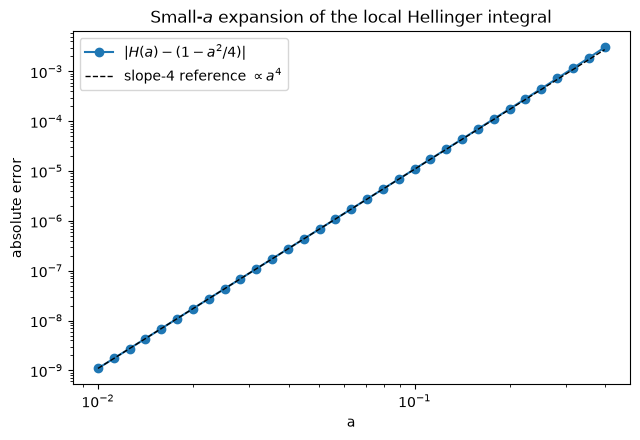

In [4]:
avals = np.logspace(-2.0, -0.4, 33)
H = hellinger_local(avals)
err = np.abs(H - (1 - avals ** 2 / 4))

slope = np.polyfit(np.log(avals), np.log(err), 1)[0]
print(f"fitted log-log slope of |H(a) - (1 - a^2/4)|: {slope:.3f}  (expected: 4)")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(avals, err, "o-", label=r"$|H(a) - (1 - a^2/4)|$")
ax.loglog(avals, err[0] * (avals / avals[0]) ** 4, "k--", lw=1, label=r"slope-4 reference $\propto a^4$")
ax.set_xlabel("a")
ax.set_ylabel("absolute error")
ax.set_title(r"Small-$a$ expansion of the local Hellinger integral")
ax.legend()
fig.tight_layout()
plt.show()

**Interpretation.** The partial Hellinger products behave in two sharply
different ways across $\sigma = 1/2$. For $\sigma \le 1/2$ they keep shrinking as
more primes are included — at $\sigma = 0.35$ the product drops by an order of
magnitude between $X = 10^2$ and $X = 10^4$, consistent with convergence to $0$
(mutual singularity). For $\sigma$ comfortably above $1/2$ the curves for
$X = 10^3$ and $X = 10^4$ are nearly indistinguishable: the product stabilizes at
a nonzero value (equivalence). The mechanism is quantitative: the numerically
confirmed expansion $H(a) = 1 - a^2/4 + O(a^4)$ (fitted log-log slope $\approx 4$)
reduces convergence of $\prod_p H_p(\sigma)$ to convergence of
$\sum_p p^{-2\sigma}$, which flips exactly at $\sigma = 1/2$. Finite products can
only *suggest* the dichotomy — at $\sigma$ slightly above $1/2$ the products still
drift because $\sum p^{-2\sigma}$ converges slowly — but the trend matches
Kakutani's theorem, which is where the actual proof lives.